# VQBR Step-by-Step Tutorial
This notebook reproduces the logic of `src/vqbr/vqbr.py` directly, without importing from the `vqbr` module.
All cells are plain top-level code so you can inspect and debug each intermediate value.

## 0) Imports

In [1]:
!pip install qiskit_aer

In [2]:
import numpy as np
from scipy.optimize import minimize
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import StatePreparation
from qiskit.quantum_info import Statevector, Operator, SparsePauliOp
import matplotlib.pyplot as plt

try:
    from qiskit.circuit.library import efficient_su2
    has_efficient_su2 = True
except Exception:
    from qiskit.circuit.library import EfficientSU2
    has_efficient_su2 = False

from qiskit_aer import AerSimulator

np.set_printoptions(precision=6, suppress=True)


## 1) Hyperparameters and Data

In [ ]:
random_state = 123
rng = np.random.default_rng(random_state)

# Measurement-based estimator knobs
shots = 4096
use_shot_noise = False

# COBYLA budget knobs
num_epochs = 10
maxiter_per_batch = 100
optimizer = "COBYLA"

# Batch-size setting for comparison
# Set batch_size = n_samples to isolate "single long COBYLA" vs "epoch-restarted COBYLA".
use_full_batch_for_comparison = True

# Ansatz knobs
reps = 2
su2_gates = ("ry", "x")
entanglement = "linear"

# Objective knobs
eps = 1e-12
loss = "neg_ratio"

# Backend knobs
prefer_gpu = False
require_gpu = False

n_samples = 50
n_features = 10
noise_std = 0.1

if use_full_batch_for_comparison:
    batch_size = n_samples
else:
    batch_size = min(10, n_samples)

true_w = rng.normal(0.0, 1.0, size=n_features)
X = rng.normal(5.0, 1.0, size=(n_samples, n_features))
y = X @ true_w + rng.normal(0.0, noise_std, size=n_samples)

m0 = rng.normal(0.0, 0.3, size=n_features)
Sigma0 = np.diag(np.full(n_features, 1.0, dtype=float))
V = 1e-3

total_cobyla_budget = int(num_epochs * maxiter_per_batch)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("m0 shape:", m0.shape)
print("Sigma0 shape:", Sigma0.shape)
print("V:", V)
print("optimizer:", optimizer)
print("num_epochs:", num_epochs)
print("batch_size:", batch_size)
print("maxiter_per_batch:", maxiter_per_batch)
print("total_cobyla_budget (num_epochs * maxiter_per_batch):", total_cobyla_budget)
print("shots:", shots)
print("use_shot_noise:", use_shot_noise)


## 2) Input Validation (mirrors `_validate_and_prepare_inputs`)

In [4]:
X = np.asarray(X, dtype=float)
y = np.asarray(y, dtype=float).reshape(-1)
m0 = np.asarray(m0, dtype=float).reshape(-1)
Sigma0 = np.asarray(Sigma0, dtype=float)

if X.ndim != 2:
    raise ValueError(f"X must be 2D, got shape={X.shape}.")

n_samples, n_features = X.shape
if y.shape[0] != n_samples:
    raise ValueError(f"y must have length {n_samples}, got {y.shape[0]}.")
if m0.shape[0] != n_features:
    raise ValueError(f"m0 must have length {n_features}, got {m0.shape[0]}.")

if Sigma0.ndim == 1:
    if Sigma0.shape[0] != n_features:
        raise ValueError(f"Sigma0 must have length {n_features}, got {Sigma0.shape[0]}.")
    if np.any(Sigma0 <= 0.0):
        raise ValueError("All entries of 1D Sigma0 must be positive.")
    Sigma0_matrix = np.diag(Sigma0.copy())
elif Sigma0.ndim == 2:
    if Sigma0.shape != (n_features, n_features):
        raise ValueError(f"Sigma0 must be ({n_features}, {n_features}), got {Sigma0.shape}.")
    if not np.allclose(Sigma0, Sigma0.T, atol=1e-12):
        raise ValueError("Sigma0 must be symmetric.")
    np.linalg.cholesky(Sigma0)
    Sigma0_matrix = Sigma0.copy()
else:
    raise ValueError("Sigma0 must be either a 1D diagonal vector or a 2D matrix.")

V = float(V)
if V < 0.0:
    raise ValueError("V must be non-negative.")

print("Validation passed.")
print("Sigma0_matrix shape:", Sigma0_matrix.shape)

Validation passed.
Sigma0_matrix shape: (10, 10)


## 3) Dimension Setup and Backend Selection

In [5]:
num_qubits = int(np.ceil(np.log2(n_features)))
state_dim = 2 ** num_qubits

statevector_backend = None
simulator_device = "CPU"
simulator_backend = "statevector_cpu"
simulator_reason = "Using CPU statevector simulator."

if not prefer_gpu:
    simulator_reason = "Using CPU statevector simulator (prefer_gpu=False)."
else:
    if AerSimulator is None:
        simulator_reason = "Using CPU statevector simulator (qiskit-aer unavailable)."
        if require_gpu:
            raise RuntimeError("GPU required but qiskit-aer is unavailable.")
    else:
        available_devices = set()
        if hasattr(AerSimulator, "available_devices"):
            try:
                available_devices = {str(d).strip().upper() for d in AerSimulator.available_devices()}
            except Exception:
                available_devices = set()
        if not available_devices:
            try:
                available_devices = {str(d).strip().upper() for d in AerSimulator().available_devices()}
            except Exception:
                available_devices = set()

        if available_devices and "GPU" not in available_devices:
            simulator_reason = "Using CPU statevector simulator (GPU unavailable)."
            if require_gpu:
                raise RuntimeError("GPU required but no GPU device reported by Aer.")
        else:
            try:
                statevector_backend = AerSimulator(method="statevector", device="GPU")
                simulator_device = "GPU"
                simulator_backend = "AerSimulator(statevector,GPU)"
                simulator_reason = "Using AerSimulator(method='statevector', device='GPU')."
            except Exception:
                simulator_reason = "Using CPU statevector simulator (Aer GPU init failed)."
                if require_gpu:
                    raise RuntimeError("GPU required but Aer GPU initialization failed.")

print("[VQBR] backend=" + simulator_backend + ", device=" + simulator_device + ", reason=" + simulator_reason)
print("num_qubits:", num_qubits)
print("state_dim:", state_dim)

[VQBR] backend=statevector_cpu, device=CPU, reason=Using CPU statevector simulator (prefer_gpu=False).
num_qubits: 4
state_dim: 16


## 4) Precision Matrix, Diagonal Detection, and Padding

In [6]:
eye = np.eye(Sigma0_matrix.shape[0], dtype=float)
precision = np.linalg.solve(Sigma0_matrix, eye)
precision = 0.5 * (precision + precision.T)

precision_diag = np.diag(precision)
off_diag = precision - np.diag(precision_diag)
precision_is_diagonal = bool(np.allclose(off_diag, 0.0, atol=1e-12))

if precision_diag.ndim != 1 or precision_diag.size == 0:
    raise ValueError("precision_diag must be a non-empty 1D vector.")

target_dim = 2 ** int(np.ceil(np.log2(precision_diag.size)))
if precision_diag.size == target_dim:
    precision_diag_padded = precision_diag.copy()
else:
    precision_diag_padded = np.pad(precision_diag, (0, target_dim - precision_diag.size), mode="constant")

print("precision shape:", precision.shape)
print("precision_is_diagonal:", precision_is_diagonal)
print("precision_diag_padded shape:", precision_diag_padded.shape)

precision shape: (10, 10)
precision_is_diagonal: True
precision_diag_padded shape: (16,)


## 5) Build `Ux_i` Gates and Row Norms

In [7]:
row_norms = np.linalg.norm(X, axis=1)
if np.any(row_norms <= 0.0):
    raise ValueError("Each row in X must have non-zero norm for normalized state encoding.")

Uxi_gates = []
for i in range(n_samples):
    vec = np.asarray(X[i], dtype=complex).reshape(-1)
    row_target_dim = 2 ** int(np.ceil(np.log2(vec.size)))
    if vec.size != row_target_dim:
        vec = np.pad(vec, (0, row_target_dim - vec.size), mode="constant")
    vec_norm = np.linalg.norm(vec)
    if vec_norm <= 0.0:
        raise ValueError("State preparation vector norm must be non-zero.")
    vec = vec / vec_norm

    prep = StatePreparation(vec)
    if hasattr(prep, "to_gate"):
        gate = prep.to_gate(label=f"Ux_{i}")
    else:
        gate = prep
    Uxi_gates.append(gate)

# Conditioning diagnostics: poor conditioning + nearly parallel rows make shot-noise training unstable.
gram_diagnostic = X.T @ X + float(V) * precision
gram_cond = float(np.linalg.cond(gram_diagnostic))
X_unit = X / np.linalg.norm(X, axis=1, keepdims=True)
row_cos = X_unit @ X_unit.T
avg_row_cos_offdiag = float((row_cos.sum() - np.trace(row_cos)) / (n_samples * (n_samples - 1)))

print("row_norms:", row_norms)
print("num Ux gates:", len(Uxi_gates))
print("cond(X^T X + V Sigma0^{-1}):", gram_cond)
print("avg pairwise row cosine:", avg_row_cos_offdiag)
if gram_cond > 1e3:
    print("[Warning] Ill-conditioned system: shot-noise can strongly degrade direction recovery.")


row_norms: [16.416213 17.585794 16.393351 16.322329 15.292099 15.237647 16.968004
 15.907288 16.673505 17.485018 15.258274 16.743043 17.433078 16.826836
 15.44971  15.51173  17.568606 15.577503 15.689737 16.932569 16.733881
 17.284711 14.006277 17.112622 14.90571  16.229901 15.69255  14.451339
 16.115349 16.436198 16.53254  15.708547 15.656972 17.025652 16.900303
 16.558174 13.814526 15.695643 18.030397 15.918304 14.87288  15.586366
 15.25932  15.816577 17.599919 16.266302 15.279794 15.541365 14.927715
 17.031465]
num Ux gates: 50
cond(X^T X + V Sigma0^{-1}): 683.0708112145155
avg pairwise row cosine: 0.9647395290158164


## 6) Build Prior Gate `Uc` from `c = V * precision @ m0`

In [8]:
c = V * (precision @ m0)
c_norm = float(np.linalg.norm(c))
Uc_gate = None

if c_norm > 0.0:
    c_vec = np.asarray(c, dtype=complex).reshape(-1)
    c_target_dim = 2 ** int(np.ceil(np.log2(c_vec.size)))
    if c_vec.size != c_target_dim:
        c_vec = np.pad(c_vec, (0, c_target_dim - c_vec.size), mode="constant")
    c_vec = c_vec / np.linalg.norm(c_vec)

    prep_c = StatePreparation(c_vec)
    if hasattr(prep_c, "to_gate"):
        Uc_gate = prep_c.to_gate(label="Uc")
    else:
        Uc_gate = prep_c

print("c:", c)
print("c_norm:", c_norm)
print("Uc_gate exists:", Uc_gate is not None)

c: [ 0.000006  0.000322  0.000214  0.000306 -0.000122  0.000274  0.000435
  0.000169 -0.000417  0.000085]
c_norm: 0.0008557255964997996
Uc_gate exists: True


## 7) Build Ansatz and Initial Parameters

In [9]:
if has_efficient_su2:
    ansatz = efficient_su2(
        num_qubits,
        su2_gates=list(su2_gates),
        entanglement=entanglement,
        reps=reps,
    )
else:
    ansatz = EfficientSU2(
        num_qubits,
        su2_gates=list(su2_gates),
        entanglement=entanglement,
        reps=reps,
    )

theta_params = list(ansatz.parameters)
num_params = len(theta_params)
theta_init = 0.01 * rng.standard_normal(num_params)

print(ansatz)
print("num_params:", num_params)
print("theta_init:", theta_init)

     ┌──────────┐┌───┐     ┌──────────┐   ┌───┐                     »
q_0: ┤ Ry(θ[0]) ├┤ X ├──■──┤ Ry(θ[4]) ├───┤ X ├──────────────────■──»
     ├──────────┤├───┤┌─┴─┐└──────────┘┌──┴───┴───┐   ┌───┐    ┌─┴─┐»
q_1: ┤ Ry(θ[1]) ├┤ X ├┤ X ├─────■──────┤ Ry(θ[5]) ├───┤ X ├────┤ X ├»
     ├──────────┤├───┤└───┘   ┌─┴─┐    └──────────┘┌──┴───┴───┐├───┤»
q_2: ┤ Ry(θ[2]) ├┤ X ├────────┤ X ├─────────■──────┤ Ry(θ[6]) ├┤ X ├»
     ├──────────┤├───┤        └───┘       ┌─┴─┐    ├──────────┤├───┤»
q_3: ┤ Ry(θ[3]) ├┤ X ├────────────────────┤ X ├────┤ Ry(θ[7]) ├┤ X ├»
     └──────────┘└───┘                    └───┘    └──────────┘└───┘»
«     ┌──────────┐   ┌───┐                      
«q_0: ┤ Ry(θ[8]) ├───┤ X ├──────────────────────
«     └──────────┘┌──┴───┴───┐    ┌───┐         
«q_1: ─────■──────┤ Ry(θ[9]) ├────┤ X ├─────────
«        ┌─┴─┐    └──────────┘┌───┴───┴───┐┌───┐
«q_2: ───┤ X ├─────────■──────┤ Ry(θ[10]) ├┤ X ├
«        └───┘       ┌─┴─┐    ├───────────┤├───┤
«q_3: ───────────────┤ X ├─

## 8) One Full Objective Evaluation (`a_hat`, `c_hat`, `d_hat`, `e_hat`, `h_hat`, `L_tilde`)

This section uses measurement estimators in two modes:
- `use_shot_noise=True`: finite-shot sampling (hardware-like).
- `use_shot_noise=False`: analytic expectation values (infinite-shot debug mode).


In [10]:
# Measurement-based estimators for a_hat, c_hat, d_hat, e_hat
if use_shot_noise and AerSimulator is None:
    raise RuntimeError("qiskit-aer is required for finite-shot estimation.")

sampling_backend = AerSimulator() if use_shot_noise else None
print("estimation mode:", "finite-shot" if use_shot_noise else "analytic (infinite-shot)")

M_pad = np.zeros((state_dim, state_dim), dtype=complex)
M_pad[:n_features, :n_features] = V * precision

# Precompute Pauli decomposition only for dense-precision finite-shot mode.
dense_pauli_terms = None
if (not precision_is_diagonal) and use_shot_noise:
    dense_pauli = SparsePauliOp.from_operator(Operator(M_pad)).simplify(atol=1e-12)
    dense_pauli_terms = []
    for label, coeff in zip(dense_pauli.paulis.to_labels(), dense_pauli.coeffs):
        if abs(coeff) > 1e-12:
            dense_pauli_terms.append((label, complex(coeff)))
    print("dense Pauli terms:", len(dense_pauli_terms))

def run_shot_counts(qc, shots):
    qc_meas = qc.copy()
    qc_meas.measure_all()
    compiled = transpile(qc_meas, sampling_backend, optimization_level=0)
    result = sampling_backend.run(compiled, shots=shots).result()
    counts = result.get_counts(compiled)
    if isinstance(counts, list):
        counts = counts[0]
    total = int(sum(counts.values()))
    if total <= 0:
        raise RuntimeError("No counts returned from sampler backend.")
    return counts, total

def ancilla_p0_exact(qc):
    # Qubit-0 (ancilla) is the least-significant qubit in statevector indexing.
    sv = np.asarray(Statevector.from_instruction(qc).data, dtype=complex)
    probs = np.abs(sv) ** 2
    return float(np.sum(probs[::2]))

def estimate_overlap_shots(Uv_gate, theta_vec, shots):
    qc = QuantumCircuit(1 + num_qubits)
    anc = 0
    work = list(range(1, 1 + num_qubits))

    qc.h(anc)
    qc.x(anc)
    qc.append(Uv_gate.control(1), [anc] + work)
    qc.x(anc)

    theta_bind = {p: float(v) for p, v in zip(theta_params, theta_vec)}
    bound_ansatz = ansatz.assign_parameters(theta_bind, inplace=False)
    qc.append(bound_ansatz.to_gate(label="Utheta").control(1), [anc] + work)
    qc.h(anc)

    if use_shot_noise:
        counts, total = run_shot_counts(qc, shots)
        # Bitstring order is c[n-1]...c[0], so ancilla q0 is rightmost char.
        n0 = sum(cnt for bitstr, cnt in counts.items() if bitstr[-1] == "0")
        p0 = float(n0) / float(total)
    else:
        p0 = ancilla_p0_exact(qc)

    return float(np.clip(2.0 * p0 - 1.0, -1.0, 1.0))

def estimate_d_hat_shots(theta_vec, shots):
    theta_bind = {p: float(v) for p, v in zip(theta_params, theta_vec)}
    bound_ansatz = ansatz.assign_parameters(theta_bind, inplace=False)

    qc = QuantumCircuit(num_qubits)
    qc.compose(bound_ansatz, inplace=True)

    if precision_is_diagonal:
        if use_shot_noise:
            counts, total = run_shot_counts(qc, shots)
            d_hat = 0.0
            for bitstr, cnt in counts.items():
                basis_index = int(bitstr, 2)
                d_hat += float(precision_diag_padded[basis_index]) * float(cnt) / float(total)
            return float(V * d_hat)

        sv = np.asarray(Statevector.from_instruction(qc).data, dtype=complex)
        probs = np.abs(sv) ** 2
        return float(V * np.dot(precision_diag_padded, probs))

    # Dense precision case
    if not use_shot_noise:
        sv = np.asarray(Statevector.from_instruction(qc).data, dtype=complex)
        return float(np.real(np.vdot(sv, M_pad @ sv)))

    if dense_pauli_terms is None:
        raise RuntimeError("Dense precision shot path requires Pauli decomposition terms.")

    d_hat = 0.0
    for label, coeff in dense_pauli_terms:
        qc_term = QuantumCircuit(num_qubits)
        qc_term.compose(bound_ansatz, inplace=True)

        # Basis change for Pauli measurement.
        for q in range(num_qubits):
            pauli_char = label[num_qubits - 1 - q]
            if pauli_char == "X":
                qc_term.h(q)
            elif pauli_char == "Y":
                qc_term.sdg(q)
                qc_term.h(q)

        counts, total = run_shot_counts(qc_term, shots)
        mu_hat = 0.0
        for bitstr, cnt in counts.items():
            parity = 1.0
            for q in range(num_qubits):
                pauli_char = label[num_qubits - 1 - q]
                if pauli_char == "I":
                    continue
                if bitstr[-1 - q] == "1":
                    parity *= -1.0
            mu_hat += parity * float(cnt) / float(total)
        d_hat += float(np.real(coeff)) * mu_hat

    return float(d_hat)

# One full-batch objective evaluation with measurement-based estimators.
theta = theta_init.copy()
batch_indices = np.arange(n_samples, dtype=int)

s = np.array([estimate_overlap_shots(Uxi_gates[i], theta, shots) for i in batch_indices], dtype=float)
r = row_norms[batch_indices]
yb = y[batch_indices]

a_hat = float(np.sum((r * s) ** 2))
c_hat = float(np.sum(yb * (r * s)))

h_hat = 0.0
e_hat = 0.0
if Uc_gate is not None and c_norm > 0.0:
    h_hat = estimate_overlap_shots(Uc_gate, theta, shots)
    e_hat = float(c_norm * h_hat)

d_hat = estimate_d_hat_shots(theta, shots)

denom = a_hat + d_hat + eps
numerator = c_hat + e_hat
if loss == "log_ratio":
    L_tilde = float(np.log(denom) - 2.0 * np.log(np.abs(numerator) + eps))
else:
    L_tilde = float(-((numerator * numerator) / denom))

print("a_hat:", a_hat)
print("c_hat:", c_hat)
print("d_hat:", d_hat)
print("e_hat:", e_hat)
print("h_hat:", h_hat)
print("L_tilde:", L_tilde)


estimation mode: analytic (infinite-shot)


a_hat: 1240.9847178817001
c_hat: 1195.4340588962527
d_hat: 0.0009997317710707903
e_hat: 7.307089912914442e-05
h_hat: 0.08539057313235521
L_tilde: -1151.5545614983184


## 9) Compare Two Training Schedules (Same Total COBYLA Budget)

We compare:
1. **Single long call**: one COBYLA run with `maxiter = num_epochs * maxiter_per_batch`.
2. **Epoch-restarted**: `num_epochs` COBYLA runs, each with `maxiter = maxiter_per_batch`, warm-starting from the previous epoch.

When `batch_size = n_samples`, both schedules optimize the full-data objective and differ mainly by whether COBYLA is restarted.


In [11]:
# Objective helper
def compute_batch_loss(theta_vec, batch_indices, scale_to_full=True):
    batch_indices = np.asarray(batch_indices, dtype=int).reshape(-1)
    if batch_indices.size == 0:
        raise ValueError("batch_indices must not be empty.")

    s = np.array([estimate_overlap_shots(Uxi_gates[i], theta_vec, shots) for i in batch_indices], dtype=float)
    r = row_norms[batch_indices]
    yb = y[batch_indices]

    # Scale data terms so a mini-batch approximates the full-data objective.
    scale = float(n_samples / batch_indices.size) if scale_to_full else 1.0
    a_hat = float(scale * np.sum((r * s) ** 2))
    c_hat = float(scale * np.sum(yb * (r * s)))

    h_hat = 0.0
    e_hat = 0.0
    if Uc_gate is not None and c_norm > 0.0:
        h_hat = estimate_overlap_shots(Uc_gate, theta_vec, shots)
        e_hat = float(c_norm * h_hat)

    d_hat = estimate_d_hat_shots(theta_vec, shots)

    denom = a_hat + d_hat + eps
    numerator = c_hat + e_hat
    if loss == "log_ratio":
        L_tilde = float(np.log(denom) - 2.0 * np.log(np.abs(numerator) + eps))
    else:
        L_tilde = float(-((numerator * numerator) / denom))

    snapshot = {
        "L_tilde": L_tilde,
        "a_hat": a_hat,
        "c_hat": c_hat,
        "d_hat": d_hat,
        "e_hat": e_hat,
        "h_hat": h_hat,
    }
    return L_tilde, snapshot

batch_size = int(max(1, min(batch_size, n_samples)))
full_indices = np.arange(n_samples, dtype=int)

# For this comparison we force full-batch objective in both schedules.
compare_indices = full_indices.copy()

# Shared initial point for fair comparison.
theta_start = theta_init.copy()

# ---- Schedule A: Single long COBYLA call ----
single_loss_history = []

def objective_single(theta_vec):
    lval, _ = compute_batch_loss(theta_vec, compare_indices, scale_to_full=False)
    mean_loss = float(lval)
    single_loss_history.append(mean_loss)
    return mean_loss

res_single = minimize(
    objective_single,
    theta_start,
    method=optimizer,
    options={"maxiter": total_cobyla_budget},
)

theta_single = np.asarray(res_single.x, dtype=float)
single_loss_history = np.asarray(single_loss_history, dtype=float)

# ---- Schedule B: Epoch-restarted COBYLA ----
restart_loss_history = []
restart_epoch_losses = []
restart_epoch_statuses = []

theta_restart = theta_start.copy()
for epoch in range(num_epochs):

    def objective_restart(theta_vec):
        lval, _ = compute_batch_loss(theta_vec, compare_indices, scale_to_full=False)
        mean_loss = float(lval)
        restart_loss_history.append(mean_loss)
        return mean_loss

    res_epoch = minimize(
        objective_restart,
        theta_restart,
        method=optimizer,
        options={"maxiter": maxiter_per_batch},
    )

    theta_restart = np.asarray(res_epoch.x, dtype=float)
    restart_epoch_statuses.append(int(res_epoch.status))

    epoch_full_loss, _ = compute_batch_loss(theta_restart, compare_indices, scale_to_full=False)
    restart_epoch_losses.append(epoch_full_loss)
    print(f"Restart epoch {epoch + 1:02d}/{num_epochs}: full_loss={epoch_full_loss:.6f}")

restart_loss_history = np.asarray(restart_loss_history, dtype=float)
restart_epoch_losses = np.asarray(restart_epoch_losses, dtype=float)

theta_candidates = {
    "single_long": theta_single,
    "epoch_restarted": theta_restart,
}

# Final objective snapshots
def final_snapshot(theta_vec):
    lval, snap = compute_batch_loss(theta_vec, compare_indices, scale_to_full=False)
    mean_loss = float(lval)
    mean_snap = {k: float(v) for k, v in snap.items()}
    return mean_loss, mean_snap

single_final_loss, single_snapshot = final_snapshot(theta_single)
restart_final_loss, restart_snapshot = final_snapshot(theta_restart)

schedule_results = {
    "single_long": {
        "final_loss": single_final_loss,
        "snapshot": single_snapshot,
        "objective_calls": int(len(single_loss_history)),
        "success": bool(res_single.success),
        "status": int(res_single.status),
        "message": str(res_single.message),
    },
    "epoch_restarted": {
        "final_loss": restart_final_loss,
        "snapshot": restart_snapshot,
        "objective_calls": int(len(restart_loss_history)),
        "success": bool(np.all(np.array(restart_epoch_statuses) == 1)),
        "status": int(restart_epoch_statuses[-1]) if len(restart_epoch_statuses) else -1,
        "message": "Last epoch status code from restarted COBYLA.",
    },
}

best_strategy = "epoch_restarted" if restart_final_loss < single_final_loss else "single_long"
best_theta = theta_candidates[best_strategy].copy()
loss_history = restart_loss_history.copy()  # keep compatibility with downstream cells

print("Training comparison summary:")
print("  single_long final loss:", single_final_loss)
print("  epoch_restarted final loss:", restart_final_loss)
print("  single_long objective calls:", len(single_loss_history))
print("  epoch_restarted objective calls:", len(restart_loss_history))
print("  selected best_strategy:", best_strategy)


Restart epoch 01/10: full_loss=-1461.824104
Restart epoch 02/10: full_loss=-1470.347972
Restart epoch 03/10: full_loss=-1473.612927
Restart epoch 04/10: full_loss=-1474.772060
Restart epoch 05/10: full_loss=-1475.065318
Restart epoch 06/10: full_loss=-1475.375904
Restart epoch 07/10: full_loss=-1476.345979
Restart epoch 08/10: full_loss=-1476.758315
Restart epoch 09/10: full_loss=-1478.127109
Restart epoch 10/10: full_loss=-1480.179471
Training comparison summary:
  single_long final loss: -1485.4891439160297
  epoch_restarted final loss: -1480.179471327205
  single_long objective calls: 1000
  epoch_restarted objective calls: 1000
  selected best_strategy: single_long


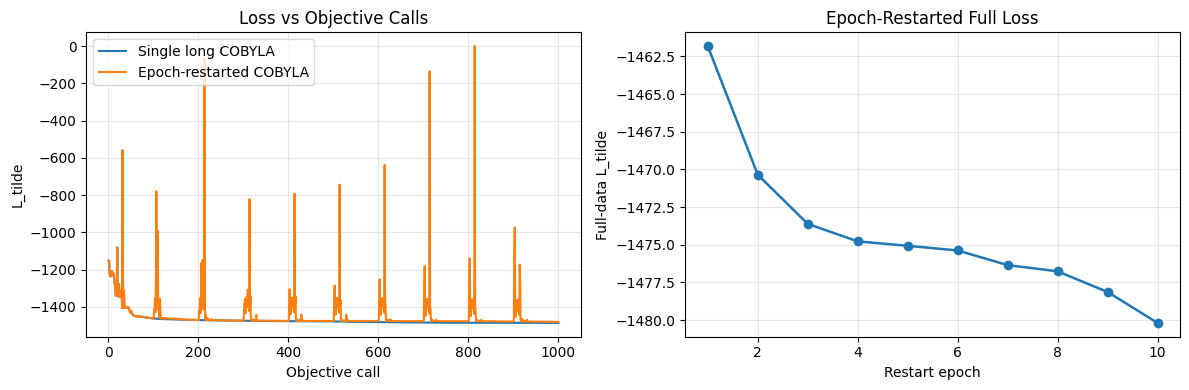

single_long calls: 1000
epoch_restarted calls: 1000
single_long final loss: -1485.4891439160297
epoch_restarted final loss: -1480.179471327205


In [12]:
# Comparison plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (Left) Objective-call trajectories
calls_single = np.arange(1, len(single_loss_history) + 1)
calls_restart = np.arange(1, len(restart_loss_history) + 1)
axes[0].plot(calls_single, single_loss_history, linewidth=1.5, label="Single long COBYLA")
axes[0].plot(calls_restart, restart_loss_history, linewidth=1.5, label="Epoch-restarted COBYLA")
axes[0].set_xlabel("Objective call")
axes[0].set_ylabel("L_tilde")
axes[0].set_title("Loss vs Objective Calls")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# (Right) Restart schedule per-epoch full-data loss
epochs = np.arange(1, len(restart_epoch_losses) + 1)
axes[1].plot(epochs, restart_epoch_losses, marker="o", linewidth=1.8)
axes[1].set_xlabel("Restart epoch")
axes[1].set_ylabel("Full-data L_tilde")
axes[1].set_title("Epoch-Restarted Full Loss")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("single_long calls:", len(single_loss_history))
print("epoch_restarted calls:", len(restart_loss_history))
print("single_long final loss:", schedule_results["single_long"]["final_loss"])
print("epoch_restarted final loss:", schedule_results["epoch_restarted"]["final_loss"])


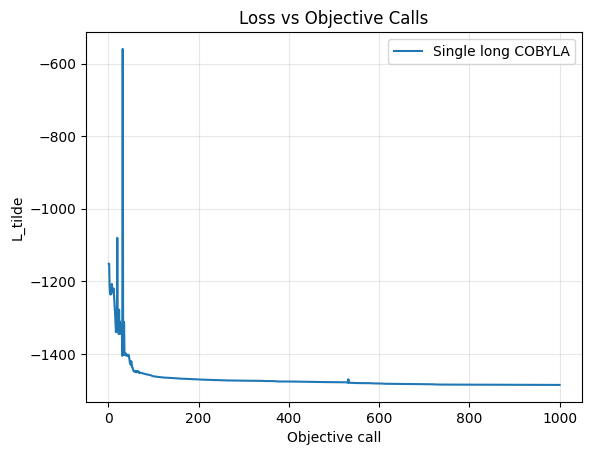

In [13]:
calls_single = np.arange(1, len(single_loss_history) + 1)
# calls_restart = np.arange(1, len(restart_loss_history) + 1)
plt.plot(calls_single, single_loss_history, linewidth=1.5, label="Single long COBYLA")
# plt.plot(calls_restart, restart_loss_history, linewidth=1.5, label="Epoch-restarted COBYLA")
plt.xlabel("Objective call")
plt.ylabel("L_tilde")
plt.title("Loss vs Objective Calls")
plt.grid(True, alpha=0.3)
plt.legend()

## 10) Build Final State(s) from Both Trained Thetas


In [14]:
def theta_to_state(theta_vec):
    qc = QuantumCircuit(num_qubits)
    theta_bind = {p: float(v) for p, v in zip(theta_params, theta_vec)}
    bound_ansatz = ansatz.assign_parameters(theta_bind, inplace=False)
    qc.compose(bound_ansatz, inplace=True)

    if statevector_backend is None:
        st = np.asarray(Statevector.from_instruction(qc).data, dtype=complex)
    else:
        qc_sim = qc.copy()
        if hasattr(qc_sim, "save_statevector"):
            qc_sim.save_statevector()
        result = statevector_backend.run(qc_sim).result()
        sv_data = None
        try:
            data = result.data(0)
            sv_data = data.get("statevector")
            if sv_data is None:
                sv_data = data.get("final_statevector")
        except Exception:
            sv_data = None
        if sv_data is None:
            sv_data = result.get_statevector(qc_sim)
        st = np.asarray(sv_data, dtype=complex)

    st = st / np.linalg.norm(st)
    return st

trained_states = {name: theta_to_state(theta) for name, theta in theta_candidates.items()}
trained_state = trained_states[best_strategy]  # keep downstream compatibility

for name, st in trained_states.items():
    pad_mass = float(np.sum(np.abs(st[n_features:]) ** 2))
    print(f"{name}: norm={np.linalg.norm(st):.6f}, padding_mass={pad_mass:.6f}")
print("best_strategy used for default trained_state:", best_strategy)


single_long: norm=1.000000, padding_mass=0.069812
epoch_restarted: norm=1.000000, padding_mass=0.140863
best_strategy used for default trained_state: single_long


## 11) Compare Both Schedules Against Closed-Form MAP Direction


In [15]:
sigma_inv = np.linalg.inv(Sigma0_matrix)
gram = X.T @ X + float(V) * sigma_inv
rhs = X.T @ y + float(V) * (sigma_inv @ m0)
w_star = np.linalg.solve(gram, rhs)

w_dir = w_star / np.linalg.norm(w_star)
w_dir_pad = np.pad(w_dir, (0, state_dim - n_features), mode="constant")
w_dir_pad = w_dir_pad / np.linalg.norm(w_dir_pad)

schedule_metrics = {}
for name, st in trained_states.items():
    overlap = np.vdot(w_dir_pad, st)
    phase = np.exp(-1j * np.angle(overlap))
    aligned_state = st * phase

    fidelity = float(np.abs(np.vdot(w_dir_pad, st)) ** 2)
    cosine_state = float(np.real(np.vdot(w_dir_pad, aligned_state)))

    feature_vec = np.real_if_close(aligned_state[:n_features], tol=1000)
    if np.iscomplexobj(feature_vec):
        feature_vec = np.real(feature_vec)
    feature_vec = np.asarray(feature_vec, dtype=float).reshape(-1)

    if np.linalg.norm(feature_vec) > 0.0:
        feature_dir = feature_vec / np.linalg.norm(feature_vec)
        if float(np.dot(feature_dir, w_dir)) < 0.0:
            feature_dir = -feature_dir
        reconstructed_w = np.linalg.norm(w_star) * feature_dir
        feature_cosine = float(np.abs(np.vdot(w_dir, feature_dir)))
    else:
        reconstructed_w = np.zeros_like(w_star)
        feature_cosine = 0.0

    relative_l2 = float(np.linalg.norm(reconstructed_w - w_star) / np.linalg.norm(w_star))

    schedule_metrics[name] = {
        "fidelity": fidelity,
        "state_cosine": cosine_state,
        "feature_cosine": feature_cosine,
        "relative_l2": relative_l2,
    }

print("Schedule comparison metrics:")
for name, met in schedule_metrics.items():
    print(f"- {name}")
    print("  fidelity:", met["fidelity"])
    print("  state cosine:", met["state_cosine"])
    print("  feature cosine:", met["feature_cosine"])
    print("  relative L2:", met["relative_l2"])

winner_by_feature = max(schedule_metrics.keys(), key=lambda k: schedule_metrics[k]["feature_cosine"])
winner_by_l2 = min(schedule_metrics.keys(), key=lambda k: schedule_metrics[k]["relative_l2"])
print("winner by feature cosine:", winner_by_feature)
print("winner by relative L2:", winner_by_l2)


Schedule comparison metrics:
- single_long
  fidelity: 0.9256994075820411
  state cosine: 0.9621327390656869
  feature cosine: 0.9975843687466139
  relative L2: 0.0695072838396969
- epoch_restarted
  fidelity: 0.8378992388341078
  state cosine: 0.9153683623733714
  feature cosine: 0.9875626109299157
  relative L2: 0.15771739961135775
winner by feature cosine: single_long
winner by relative L2: single_long


## 12) Inspect One Overlap Circuit

In [16]:
sample_i = 0
qc_show = QuantumCircuit(1 + num_qubits)
anc = 0
work = list(range(1, 1 + num_qubits))

qc_show.h(anc)
qc_show.x(anc)
qc_show.append(Uxi_gates[sample_i].control(1), [anc] + work)
qc_show.x(anc)

theta_bind = {p: float(v) for p, v in zip(theta_params, best_theta)}
bound_ansatz = ansatz.assign_parameters(theta_bind, inplace=False)
qc_show.append(bound_ansatz.to_gate(label="Utheta").control(1), [anc] + work)
qc_show.h(anc)

print(qc_show.decompose(reps=1).draw(output="text"))

     ┌────────────┐┌──────────┐                                          »
q_0: ┤ U(π/2,0,π) ├┤ U(π,0,π) ├─────────■────────────────────■───────────»
     └────────────┘└──────────┘┌────────┴─────────┐          │           »
q_1: ──────────────────────────┤ U(π/2,-5.87,0,0) ├──────────┼───────────»
                               └──────────────────┘┌─────────┴──────────┐»
q_2: ──────────────────────────────────────────────┤ U(π/2,-5.4492,0,0) ├»
                                                   └────────────────────┘»
q_3: ────────────────────────────────────────────────────────────────────»
                                                                         »
q_4: ────────────────────────────────────────────────────────────────────»
                                                                         »
«                                                                           »
«q_0: ──────────■───────────────────■────────────■─────────────■────────────»
«               │  

This notebook is self-contained and uses measurement estimators for training (`a_hat`, `c_hat`, `d_hat`, `e_hat`).
Set `use_shot_noise=True` for finite-shot sampling, or `use_shot_noise=False` for analytic (infinite-shot) debug mode.
The training section compares two schedules with matched COBYLA budget: single long run vs epoch-restarted run.
